# **Dataset Formation**

This notebook explores the formation of the full NER dataset, encompassing all divans and other works.

In [1]:
%load_ext autoreload
%autoreload 2
from dataset_helpers import *
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Reading Extractions

In [5]:
dfs=[]
dir='C:/Users/Kamal/OneDrive/Documents/GitHub/dhlab-epigraphy-studies/dataset_formation/Extracted'
for directory in os.listdir(dir):
        curr_df=load_extractions_from_dir(dir+'/'+directory)
        dfs.append(curr_df)
extraction_df=pd.concat(dfs,ignore_index=True)
extraction_df['file_name']=extraction_df['file_name'].apply(lambda x :  str(x).replace('.txt',''))

In [6]:
extraction_df

,dict_term,definition,term,context,file_name,page_number,source_file
0,Վիմագիր,Ընդհանուր տերմին բոլոր քարեարձանագրությունների...,վիմագիր,արևելյան նիրակի ներկայիս ... շիրակի մարզ վիմագ...,Divan_Prak10,11,extraction_chunk_1.json
1,Վիմագիր,Ընդհանուր տերմին բոլոր քարեարձանագրությունների...,վիմագրերը,թվային ծոտոխցիկներով լուսանկարել պրակում լուսա...,Divan_Prak10,12,extraction_chunk_1.json
2,Վիմագիր,Ընդհանուր տերմին բոլոր քարեարձանագրությունների...,վիմագրերը,տեղում համեմատել վիմագրերը։ 2 ձեռքի տակ ունենա...,Divan_Prak10,12,extraction_chunk_1.json
3,Վիմագիր,Ընդհանուր տերմին բոլոր քարեարձանագրությունների...,վիմագրերը,եթե խաչի ձորի վիմագրերը թե րևս չէին կարող լինե...,Divan_Prak10,12,extraction_chunk_1.json
4,Վիմագիր,Ընդհանուր տերմին բոլոր քարեարձանագրությունների...,վիմագրերի,վիմագրերի վերծանության գրեթե հիսնամյա հեռավորո...,Divan_Prak10,11,extraction_chunk_1.json
...,...,...,...,...,...,...,...
1303,Վիմագիր,Ընդհանուր տերմին բոլոր քարե արձանագրություններ...,արձանագրություն,վիմագրեր ներկայացնում ենք միավոր արձանագրությո...,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,527,extraction_chunk_50.json
1304,Կանոնագիր,Կանոնադրական կամ իրավական նորմերի արձանագրությ...,կանոնագիր,անդամներից էին կանոնագիր անջրդիի վարդանեան կրթ...,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,523,extraction_chunk_50.json
1305,Վիմագիր,Ընդհանուր տերմին բոլոր քարե արձանագրություններ...,վիմագրեր,վիմագրեր և եկեղեցական իրերի արձանագրություններ...,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,63,extraction_chunk_7.json
1306,Վիմագիր,Ընդհանուր տերմին բոլոր քարե արձանագրություններ...,վիմագրում,և վիմագրում հիշված տեր դավիթը նույն անձն են,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,65,extraction_chunk_7.json


In [5]:
extraction_df.head()

,dict_term,definition,term,context,file_name,page_number,source_file
0,Վիմագիր,Ընդհանուր տերմին բոլոր քարեարձանագրությունների...,վիմագիր,արևելյան նիրակի ներկայիս ... շիրակի մարզ վիմագ...,Divan_Prak10,11,extraction_chunk_1.json
1,Վիմագիր,Ընդհանուր տերմին բոլոր քարեարձանագրությունների...,վիմագրերը,թվային ծոտոխցիկներով լուսանկարել պրակում լուսա...,Divan_Prak10,12,extraction_chunk_1.json
2,Վիմագիր,Ընդհանուր տերմին բոլոր քարեարձանագրությունների...,վիմագրերը,տեղում համեմատել վիմագրերը։ 2 ձեռքի տակ ունենա...,Divan_Prak10,12,extraction_chunk_1.json
3,Վիմագիր,Ընդհանուր տերմին բոլոր քարեարձանագրությունների...,վիմագրերը,եթե խաչի ձորի վիմագրերը թե րևս չէին կարող լինե...,Divan_Prak10,12,extraction_chunk_1.json
4,Վիմագիր,Ընդհանուր տերմին բոլոր քարեարձանագրությունների...,վիմագրերի,վիմագրերի վերծանության գրեթե հիսնամյա հեռավորո...,Divan_Prak10,11,extraction_chunk_1.json


## Reading Corpuses

In [6]:
extracted_corpuses=extraction_df['file_name'].apply(lambda x: str(x).replace('.txt','')).unique().tolist()
extracted_corpuses

['Divan_Prak10',
 'Divan_Prak2',
 'Divan_Prak3',
 'Divan_Prak4',
 'Divan_Prak5',
 'Divan_Prak6',
 'Divan_Prak7',
 'Divan_Prak8',
 'Divan_Prak9',
 'Divasn_Prak1',
 'ԱԿՈՒՆՔ-ԵՎ-ԿԱԹՆԱՂԲՅՈՒՐ-ԳՅՈՒՂԵՐԻ-ՊԱՏՄԱԿԱՆ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ',
 'ԱՆՏԻՊ ՎԻՄԱԳՐԵՐ ԵՐԵՎԱՆԻ ԿԱԹՈՂԻԿԵ ԵԿԵՂԵՑՈՒՑ',
 'ԱՐՄԱՎԻՐԻ ՄԱՐԶԻ ՎԻՄԱԳՐԱԿԱՆ ԺԱՌԱՆԳ',
 'ԱՐՑԱԽԻ-ԵՎ-ՍՅՈՒՆԻՔԻ-ՄԵԼԻՔԱԿԱՆ-ԱՊԱՐԱՆՔՆԵՐԸ',
 'ԱՐՙԱԽԻ-ԵՎ-ՍՅՈՒՆԻՔԻ-ՄԵԼԻՔԱԿԱՆ-ԱՊԱՐԱՆՔՆԵՐԸ',
 'Բուն-Աղվանք-1',
 'ԴԱԴԻ-ՎԱՆՔԻ-ՎԵՐԱԿԱՆԳՆՈՒՄԸ-1997-2011-ԹԹ',
 'ԷՋՄԻԱԾՆԻ ՏԱՊԱՆԱԳՐԵՐ',
 'Խոջիվանք',
 'ԿՈՎԿԱՍՅԱՆ-ԹԱՆԳԱՐԱՆԻ-ՀԱՅԿԱԿԱՆ-ՀԱՎԱՔԱԾՈՒՆ',
 'ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ']

In [40]:
cdfs=[]
for corpus in os.listdir('C:/Users/Kamal/OneDrive/Documents/GitHub/dhlab-epigraphy-studies/dataset_formation/temp'):
    if corpus.replace('_cleaned.jsonl','')  in extracted_corpuses:
        curr_df=pd.read_json('C:/Users/Kamal/OneDrive/Documents/GitHub/dhlab-epigraphy-studies/dataset_formation/temp/'+corpus,lines=True)
        curr_df.rename(columns={'page':'page_number','sentence':'cleaned_text','source_file':'file_name'},inplace=True)
        curr_df['file_name']=curr_df['file_name'].apply(lambda x: str(x).replace('.txt',''))
        cdfs.append(curr_df)
corpus_df=pd.concat(cdfs,ignore_index=True)
corpus_df.head()
        

,file_name,page_number,cleaned_text
0,Divan_Prak10,8,տպագրվում է հ գաս հնագիտության և ազգագրության ...
1,Divan_Prak10,8,խմբագրական խորհուրդ՝ գր ս գրիգորյան հ ա մելքոն...
2,Divan_Prak10,8,պրակը հրատարակության պատրաստեցին՝ պատմ գիտ թեկ...
3,Divan_Prak10,8,պատասխանատու խմբագիրներ՝ գ գ սարգսյան ա է հարո...
4,Divan_Prak10,8,դ դիվան հայ վիմագրության պրակ շիրակի մարզ կազմ...


## Merging extraction and corpus

In [43]:
complete_df=pd.merge(corpus_df,extraction_df[['page_number','term','context','file_name']],on=['file_name','page_number'],how='outer')

complete_df.head()

,file_name,page_number,cleaned_text,term,context
0,Divan_Prak10,8,տպագրվում է հ գաս հնագիտության և ազգագրության ...,վիմական արձանագրությունները,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...
1,Divan_Prak10,8,խմբագրական խորհուրդ՝ գր ս գրիգորյան հ ա մելքոն...,վիմական արձանագրությունները,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...
2,Divan_Prak10,8,պրակը հրատարակության պատրաստեցին՝ պատմ գիտ թեկ...,վիմական արձանագրությունները,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...
3,Divan_Prak10,8,պատասխանատու խմբագիրներ՝ գ գ սարգսյան ա է հարո...,վիմական արձանագրությունները,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...
4,Divan_Prak10,8,դ դիվան հայ վիմագրության պրակ շիրակի մարզ կազմ...,վիմական արձանագրությունները,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...


In [44]:
create_ner_dataset(complete_df,'complete_data.jsonl')

Dataset created! Total rows: 92200, saved to complete_data.jsonl


In [2]:
ner_data=pd.read_json('complete_data.jsonl',lines=True)
ner_data.drop_duplicates(inplace=True)
ner_data.head()

C:\Users\Kamal\AppData\Local\Temp\ipykernel_85964\231579873.py:1: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  ner_data=pd.read_json('complete_data.jsonl',lines=True)


ValueError: Expected object or value

## Statistics

In [46]:
ner_stats=ner_data.copy()
ner_stats['output']=ner_stats['output'].apply(lambda x: pd.NA if x=='' else x)

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_ner_dataset_stats(df: pd.DataFrame):
    """
    Analyzes and plots statistics from a NER dataset DataFrame.
    Expects columns: ['input', 'output', 'page_number', 'file_name'].
    """
    # 1️⃣ Add a label for positive / negative
    df = df.copy()
    df["is_positive"] = df["output"].notna() & (df["output"].astype(str).str.strip() != "")
    
    # 2️⃣ Count positive vs negative samples
    counts = df["is_positive"].value_counts().rename(index={True: "Positive", False: "Negative"}).reset_index()
    counts.columns = ["Label", "Count"]
    
    # Plot overall distribution
    plt.figure(figsize=(5, 4))
    sns.barplot(data=counts, x="Label", y="Count", palette="viridis")
    plt.title("Distribution of Positive vs Negative Samples")
    plt.ylabel("Number of Samples")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()
    
    # 3️⃣ Group by file_name
    grouped = (
        df.groupby("file_name")
          .agg(total_samples=("is_positive", "count"),
               positive_samples=("is_positive", "sum"))
          .assign(positive_rate=lambda x: x["positive_samples"] / x["total_samples"])
          .sort_values(by="positive_rate", ascending=False)
    )

    # Add average sentence length for extra insight
    grouped["avg_input_length"] = (
        df.groupby("file_name")["input"].apply(lambda x: x.str.len().mean())
    )

    print("\n📊 Top 20 file names by positive rate:\n")
    display(grouped.head(20))
    
    # 4️⃣ Plot top 20 file names by positive rate
    top_files = grouped.head(20).reset_index()
    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_files, x="file_name", y="positive_rate", palette="mako")
    plt.xticks(rotation=45, ha="right")
    plt.title("Top 20 Files by Positive Sample Rate")
    plt.ylabel("Positive Rate")
    plt.xlabel("File Name")
    plt.tight_layout()
    plt.show()
    
    # 5️⃣ Optionally return grouped stats
    return grouped


C:\Users\Kamal\AppData\Local\Temp\ipykernel_34104\634813482.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, x="Label", y="Count", palette="viridis")


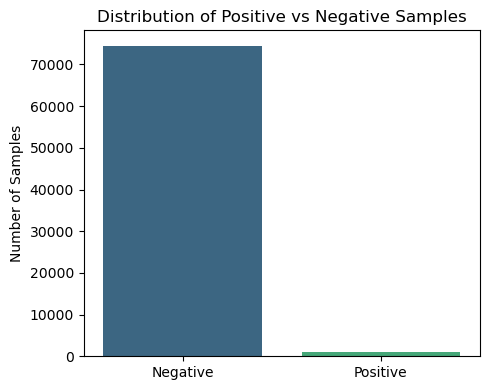


📊 Top 20 file names by positive rate:



,total_samples,positive_samples,positive_rate,avg_input_length
file_name,,,,
ԱՆՏԻՊ ՎԻՄԱԳՐԵՐ ԵՐԵՎԱՆԻ ԿԱԹՈՂԻԿԵ ԵԿԵՂԵՑՈՒՑ,174,37,0.212644,130.867816
ԱՐՄԱՎԻՐԻ ՄԱՐԶԻ ՎԻՄԱԳՐԱԿԱՆ ԺԱՌԱՆԳ,118,9,0.076271,131.915254
ԷՋՄԻԱԾՆԻ ՏԱՊԱՆԱԳՐԵՐ,206,14,0.067961,117.689320
Divan_Prak10,1815,97,0.053444,87.126722
ԱԿՈՒՆՔ-ԵՎ-ԿԱԹՆԱՂԲՅՈՒՐ-ԳՅՈՒՂԵՐԻ-ՊԱՏՄԱԿԱՆ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ,307,10,0.032573,97.628664
Divan_Prak7,3537,94,0.026576,76.592875
Divan_Prak6,4005,102,0.025468,95.762297
Divan_Prak9,7532,150,0.019915,82.776553
ԱՐՑԱԽԻ-ԵՎ-ՍՅՈՒՆԻՔԻ-ՄԵԼԻՔԱԿԱՆ-ԱՊԱՐԱՆՔՆԵՐԸ,2034,38,0.018682,149.661750


C:\Users\Kamal\AppData\Local\Temp\ipykernel_34104\634813482.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_files, x="file_name", y="positive_rate", palette="mako")


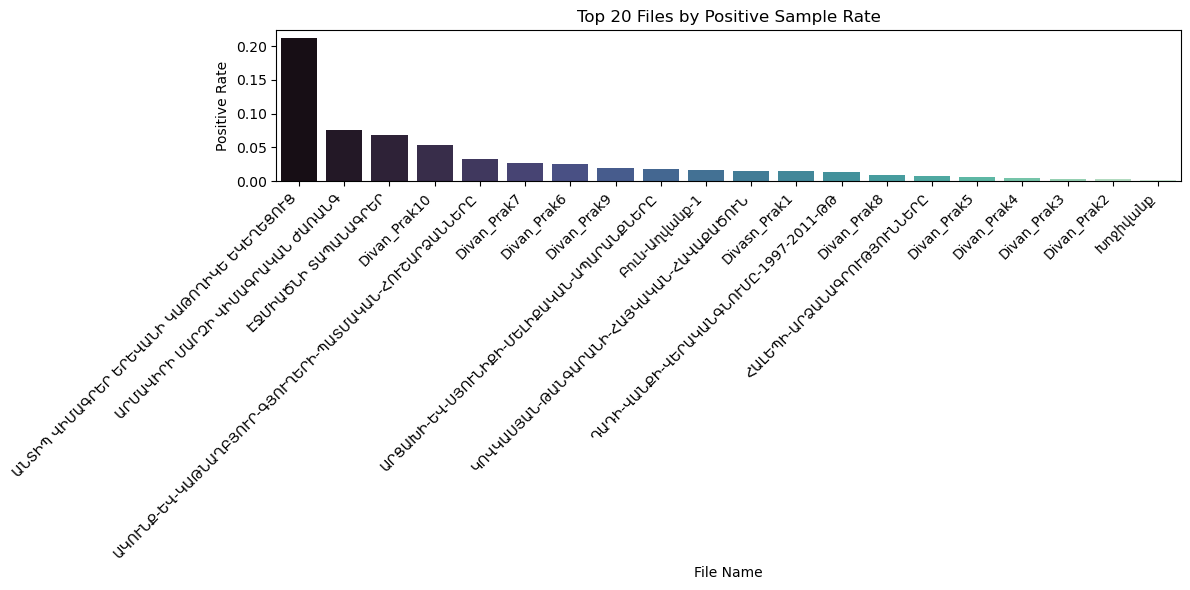

,total_samples,positive_samples,positive_rate,avg_input_length
file_name,,,,
ԱՆՏԻՊ ՎԻՄԱԳՐԵՐ ԵՐԵՎԱՆԻ ԿԱԹՈՂԻԿԵ ԵԿԵՂԵՑՈՒՑ,174,37,0.212644,130.867816
ԱՐՄԱՎԻՐԻ ՄԱՐԶԻ ՎԻՄԱԳՐԱԿԱՆ ԺԱՌԱՆԳ,118,9,0.076271,131.915254
ԷՋՄԻԱԾՆԻ ՏԱՊԱՆԱԳՐԵՐ,206,14,0.067961,117.689320
Divan_Prak10,1815,97,0.053444,87.126722
ԱԿՈՒՆՔ-ԵՎ-ԿԱԹՆԱՂԲՅՈՒՐ-ԳՅՈՒՂԵՐԻ-ՊԱՏՄԱԿԱՆ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ,307,10,0.032573,97.628664
Divan_Prak7,3537,94,0.026576,76.592875
Divan_Prak6,4005,102,0.025468,95.762297
Divan_Prak9,7532,150,0.019915,82.776553
ԱՐՑԱԽԻ-ԵՎ-ՍՅՈՒՆԻՔԻ-ՄԵԼԻՔԱԿԱՆ-ԱՊԱՐԱՆՔՆԵՐԸ,2034,38,0.018682,149.661750


In [55]:
analyze_ner_dataset_stats(ner_stats)